# Stochastic Modeling of Blackjack

## `setup_variables.py`

In [10]:
%%writefile setup_variables.py
import numpy as np
from types import SimpleNamespace

def setup_variables():

    global PLAYERfirst, PLAYERtwoHard, PLAYERhard, PLAYERtwoSoft, PLAYERsoft
    global PLAYERpair, PLAYERstand, PLAYERdoubStand, PLAYERsplit
    global PLAYERbj, PLAYERsurrender, PLAYERbust, PLAYERdoubBust, numPlayerStates

    global DEALERfirst, DEALERhard, DEALERsoft, DEALERstand
    global DEALERbj, DEALERbust, numDealerStates

    global houseRules
    global playerMoves
    global P, PD, Pinf, PSinf, PDinf
    global basic

    #%% Define playing rules
    houseRules = SimpleNamespace()
    houseRules.DSSS = 1    # Dealer stands on soft 17
    houseRules.DASA = 1    # Double after split allowed
    houseRules.MSA = 0     # Multiple splits allowed (CODE NOT CONFIGURED FOR "YES")
    houseRules.HASAA = 0   # Hit after split aces allowed (resplitting also allowed)
    houseRules.SRA = 0     # Surrender allowed (after dealer checks for bj and before player draws cards)

    # State names for player transitions
    PLAYERfirst      = np.array([0] + list(range(1, 11)))               
    PLAYERtwoHard    = np.array([0, 0, 0] + list(range(11, 29)))         
    PLAYERhard       = np.array([0, 0, 0, 0] + list(range(29, 46)))       
    PLAYERtwoSoft    = np.array([0]*11 + list(range(46, 56)))           
    PLAYERsoft       = np.array([0]*12 + list(range(56, 65)))               
    PLAYERpair       = np.array([0] + list(range(65, 75)))                  
    PLAYERstand      = np.array([0, 0, 0] + list(range(75, 93)))          
    PLAYERdoubStand  = np.array([0]*5 + list(range(93, 109)))         
    PLAYERsplit      = np.array([0] + list(range(109, 119)))             
    PLAYERbj         = 119
    PLAYERsurrender  = 120
    PLAYERbust       = 121
    PLAYERdoubBust   = 122

    numPlayerStates = PLAYERdoubBust  # 122 

    # State names for dealer transitions
    DEALERfirst      = np.array([0] + list(range(1, 11)))                    
    DEALERhard       = np.array([0, 0, 0] + list(range(11, 25)))             
    DEALERsoft       = np.array([0]*11 + list(range(25, 31)))                
    DEALERstand      = np.array([0]*16 + list(range(31, 36)))             
    DEALERbj         = 36
    DEALERbust       = 37

    numDealerStates = DEALERbust  # 37 

    # Possible moves for the player (elements of strategy tables)
    playerMoves = SimpleNamespace()
    playerMoves.S  = 0   # Stand
    playerMoves.DB = 1   # Double (else Hit)
    playerMoves.DS = 2   # Double (else Stand)
    playerMoves.H  = 3   # Hit
    playerMoves.SP = 4   # Split
    playerMoves.SR = 5   # Surrender (else Hit)

    # Transition matrices
    P  = np.zeros((11, numPlayerStates, numPlayerStates))   # Player's hand
    PD = np.zeros((numDealerStates, numDealerStates))       # Dealer's hand

    # "Infinite matrices" (all probability in absorbing states)
    Pinf  = np.zeros((11, numPlayerStates, numPlayerStates))   # Player's hand
    PSinf = np.zeros((11, numPlayerStates, numPlayerStates))   # Player's hand after splitting a pair
    PDinf = np.zeros((numDealerStates, numDealerStates))       # Dealer's hand

    #%% Basic Strategy Tables
    S  = 0 
    DB = 1  
    DS = 2  
    H  = 3  
    SP = 4  
    SR = 5  

    basic = SimpleNamespace()

    #   2  3  4  5  6  7  8  9 10  A
    basic.pairStrategyDASA = np.array([
        [ SP, SP, SP, SP, SP, SP,  H,  H,  H,  H],  # 2-2
        [ SP, SP, SP, SP, SP, SP,  H,  H,  H,  H],  # 3-3
        [  H,  H,  H, SP, SP,  H,  H,  H,  H,  H],  # 4-4
        [ DB, DB, DB, DB, DB, DB, DB, DB,  H,  H],  # 5-5
        [ SP, SP, SP, SP, SP,  H,  H,  H,  H,  H],  # 6-6
        [ SP, SP, SP, SP, SP, SP,  H,  H,  H,  H],  # 7-7
        [ SP, SP, SP, SP, SP, SP, SP, SP, SP, SP],  # 8-8
        [ SP, SP, SP, SP, SP,  S, SP, SP,  S,  S],  # 9-9
        [  S,  S,  S,  S,  S,  S,  S,  S,  S,  S],  # 10-10
        [ SP, SP, SP, SP, SP, SP, SP, SP, SP, SP],  # A-A
    ], dtype=int)

    #   2  3  4  5  6  7  8  9 10  A
    basic.pairStrategyNoDASA = np.array([
        [  H,  H, SP, SP, SP, SP,  H,  H,  H,  H],  # 2-2
        [  H,  H, SP, SP, SP, SP,  H,  H,  H,  H],  # 3-3
        [  H,  H,  H,  H,  H,  H,  H,  H,  H,  H],  # 4-4
        [ DB, DB, DB, DB, DB, DB, DB, DB,  H,  H],  # 5-5
        [  H, SP, SP, SP, SP,  H,  H,  H,  H,  H],  # 6-6
        [ SP, SP, SP, SP, SP, SP,  H,  H,  H,  H],  # 7-7
        [ SP, SP, SP, SP, SP, SP, SP, SP, SP, SP],  # 8-8
        [ SP, SP, SP, SP, SP,  S, SP, SP,  S,  S],  # 9-9
        [  S,  S,  S,  S,  S,  S,  S,  S,  S,  S],  # 10-10
        [ SP, SP, SP, SP, SP, SP, SP, SP, SP, SP],  # A-A
    ], dtype=int)

    #   2  3  4  5  6  7  8  9 10  A
    basic.softStrategy = np.array([
        [  H,  H,  H,  H, DB,  H,  H,  H,  H,  H],  # 12
        [  H,  H,  H,  H, DB,  H,  H,  H,  H,  H],  # 13
        [  H,  H,  H, DB, DB,  H,  H,  H,  H,  H],  # 14
        [  H,  H, DB, DB, DB,  H,  H,  H,  H,  H],  # 15
        [  H,  H, DB, DB, DB,  H,  H,  H,  H,  H],  # 16
        [  H, DB, DB, DB, DB,  H,  H,  H,  H,  H],  # 17
        [  S, DS, DS, DS, DS,  S,  S,  H,  H,  H],  # 18
        [  S,  S,  S,  S,  S,  S,  S,  S,  S,  S],  # 19
        [  S,  S,  S,  S,  S,  S,  S,  S,  S,  S],  # 20
        [  S,  S,  S,  S,  S,  S,  S,  S,  S,  S],  # 21
    ], dtype=int)

    #   2  3  4  5  6  7  8  9 10  A
    basic.hardStrategy = np.array([
        [  H,  H,  H,  H,  H,  H,  H,  H,  H,  H],  # 4
        [  H,  H,  H,  H,  H,  H,  H,  H,  H,  H],  # 5
        [  H,  H,  H,  H,  H,  H,  H,  H,  H,  H],  # 6
        [  H,  H,  H,  H,  H,  H,  H,  H,  H,  H],  # 7
        [  H,  H,  H,  H,  H,  H,  H,  H,  H,  H],  # 8
        [  H, DB, DB, DB, DB,  H,  H,  H,  H,  H],  # 9
        [ DB, DB, DB, DB, DB, DB, DB, DB,  H,  H],  # 10
        [ DB, DB, DB, DB, DB, DB, DB, DB, DB,  H],  # 11
        [  H,  H,  S,  S,  S,  H,  H,  H,  H,  H],  # 12
        [  S,  S,  S,  S,  S,  H,  H,  H,  H,  H],  # 13
        [  S,  S,  S,  S,  S,  H,  H,  H,  H,  H],  # 14
        [  S,  S,  S,  S,  S,  H,  H,  H, SR,  H],  # 15
        [  S,  S,  S,  S,  S,  H,  H, SR, SR, SR],  # 16
        [  S,  S,  S,  S,  S,  S,  S,  S,  S,  S],  # 17
        [  S,  S,  S,  S,  S,  S,  S,  S,  S,  S],  # 18
        [  S,  S,  S,  S,  S,  S,  S,  S,  S,  S],  # 19
        [  S,  S,  S,  S,  S,  S,  S,  S,  S,  S],  # 20
        [  S,  S,  S,  S,  S,  S,  S,  S,  S,  S],  # 21
    ], dtype=int)


Overwriting setup_variables.py


## `set_strategy.py`

In [11]:
%%writefile set_strategy.py
from types import SimpleNamespace
import setup_variables

def set_strategy(type):
    """
    Returns strategy: a namespace with fields 'bet', 'PAIR', 'SOFT', 'HARD'
    """
    # Pull the already-initialized objects out of setup_variables
    houseRules = setup_variables.houseRules
    basic       = setup_variables.basic

    if type == 'basic':
        strategy = SimpleNamespace()
        strategy.bet = 1

        if houseRules.DASA:
            strategy.PAIR = basic.pairStrategyDASA
        else:
            strategy.PAIR = basic.pairStrategyNoDASA

        strategy.HARD = basic.hardStrategy
        strategy.SOFT = basic.softStrategy
        return strategy

    else:
        print("Unknown type!")
        return None


Overwriting set_strategy.py


## `calc_dealer_trans.py`

In [12]:
%%writefile calc_dealer_trans.py
import numpy as np
from numpy.linalg import matrix_power
import setup_variables
import matplotlib.pyplot as plt

def calc_dealer_trans(deck):
    """
    Builds the dealer's transition matrix (PD) and its absorbing-power (PDinf) given the deck distribution. 
    Populates setup_variables.PD and setup_variables.PDinf.
    """
    DEALERfirst      = setup_variables.DEALERfirst
    DEALERhard       = setup_variables.DEALERhard
    DEALERsoft       = setup_variables.DEALERsoft
    DEALERstand      = setup_variables.DEALERstand
    DEALERbj         = setup_variables.DEALERbj
    DEALERbust       = setup_variables.DEALERbust

    houseRules = setup_variables.houseRules

    PD    = setup_variables.PD    # shape: (37, 37)
    PDinf = setup_variables.PDinf # shape: (37, 37)

    PD.fill(0)

    for ii in range(17, 22): 
        PD[DEALERstand[ii - 1] - 1, DEALERstand[ii - 1] - 1] = 1 

    PD[DEALERbj - 1, DEALERbj - 1] = 1
    PD[DEALERbust - 1, DEALERbust - 1] = 1
    PD[DEALERhard[17 - 1] - 1, DEALERstand[17 - 1] - 1] = 1


    # --- Set first transitions ---
    for ii in range(2, 12):         
        for dNew in range(2, 12):  
            newDtot = ii + dNew
            newDsoft = (ii == 11 or dNew == 11)
            if newDtot > 21:
                # Pair of aces
                newDtot = newDtot - 10
                newDsoft = True
            from_state = DEALERfirst[ii - 1] - 1
            if newDtot == 21:
                to_state = DEALERbj - 1 
                PD[from_state, to_state] += deck[dNew - 1]
            elif newDtot > 17:
                to_state = DEALERstand[newDtot - 1] - 1
                PD[from_state, to_state] += deck[dNew - 1]
            elif newDsoft:
                to_state = DEALERsoft[newDtot - 1] - 1
                PD[from_state, to_state] += deck[dNew - 1]
            else:
                to_state = DEALERhard[newDtot - 1] - 1
                PD[from_state, to_state] += deck[dNew - 1]



    # --- Set hard transitions for totals 4..16 ---
    for ii in range(4, 17):  
        for dNew in range(2, 12):  
            newDtot = ii + dNew
            newDsoft = (dNew == 11)
            # Handle Ace as 1 if necessary (only if sum > 21 and dNew is Ace)
            if (newDtot > 21) and newDsoft:
                newDtot -= 10
                newDsoft = False
            from_state = DEALERhard[ii - 1] - 1         
            if newDtot > 21:
                to_state = DEALERbust - 1            
                PD[from_state, to_state] += deck[dNew - 1]
            elif newDtot > 17:
                to_state = DEALERstand[newDtot - 1] - 1  
                PD[from_state, to_state] += deck[dNew - 1]
            elif newDsoft:
                to_state = DEALERsoft[newDtot - 1] - 1   
                PD[from_state, to_state] += deck[dNew - 1]
            else:
                to_state = DEALERhard[newDtot - 1] - 1   
                PD[from_state, to_state] += deck[dNew - 1]


    # --- Set soft transitions for totals 12..17 ---
    for ii in range(12, 18): 
        for dNew in range(2, 12):  
            newDtot = ii + dNew
            newDsoft = True
            if newDtot > 21:
                newDtot -= 10
                newDsoft = (dNew == 11)
            from_state = DEALERsoft[ii - 1] - 1  
            if newDtot > 17:
                to_state = DEALERstand[newDtot - 1] - 1  
                PD[from_state, to_state] += deck[dNew - 1]
            elif newDsoft:
                to_state = DEALERsoft[newDtot - 1] - 1
                PD[from_state, to_state] += deck[dNew - 1]
            else:
                to_state = DEALERhard[newDtot - 1] - 1
                PD[from_state, to_state] += deck[dNew - 1]


    # If “Dealer stands on soft 17” (DSSS), override the soft-17 row
    if houseRules.DSSS:
        PD[DEALERsoft[16] - 1, :] = 0            
        PD[DEALERsoft[16] - 1, DEALERstand[16] - 1] = 1 

    # --- Compute PDinf = PD^17 ---
    PDinf[:,:] = matrix_power(PD, 17)




    # Plot the dealer's transition matrix
    num_states = DEALERbust  # 37
    labels = [''] * num_states

    # first2…first11
    for i in range(2, 12):
        idx = DEALERfirst[i - 1] - 1
        labels[idx] = f"first{i}"

    # hard4…hard17
    for i in range(4, 18):
        idx = DEALERhard[i - 1] - 1
        labels[idx] = f"hard{i}"

    # soft12…soft17
    for i in range(12, 18):
        idx = DEALERsoft[i - 1] - 1
        labels[idx] = f"soft{i}"

    # stand17…stand21
    for i in range(17, 22):
        idx = DEALERstand[i - 1] - 1
        labels[idx] = f"stand{i}"

    # blackjack and bust
    labels[DEALERbj   - 1] = 'bj'
    labels[DEALERbust - 1] = 'bust'


    fig, ax = plt.subplots(figsize=(10, 10))
    cax = ax.imshow(PD, cmap='jet', interpolation='nearest', vmin=0, vmax=1)
    fig.colorbar(cax, ax=ax, shrink=0.75, label='')

    ax.set_xticks(np.arange(num_states))
    ax.set_yticks(np.arange(num_states))
    ax.set_xticklabels(labels, rotation=90, fontsize=6)
    ax.set_yticklabels(labels, fontsize=6)

    ax.xaxis.tick_top()                                
    ax.tick_params(axis='x', labeltop=True, labelbottom=False)  

    plt.tight_layout()
    plt.show()


    fig2, ax2 = plt.subplots(figsize=(10, 10))
    cax2 = ax2.imshow(PDinf, cmap='jet', interpolation='nearest', vmin=0, vmax=1)
    fig2.colorbar(cax2, ax=ax2, shrink=0.75, label='')

    ax2.set_xticks(np.arange(num_states))
    ax2.set_yticks(np.arange(num_states))
    ax2.set_xticklabels(labels, rotation=90, fontsize=6)
    ax2.set_yticklabels(labels, fontsize=6)

    ax2.xaxis.tick_top()
    ax2.tick_params(axis='x', labeltop=True, labelbottom=False)

    plt.tight_layout()
    plt.show()

setup_variables.setup_variables()

calc_dealer_trans(np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1], dtype=float) / 13)


Overwriting calc_dealer_trans.py


## `calc_player_trans.py`

In [13]:
%%writefile calc_player_trans.py
import numpy as np
from numpy.linalg import matrix_power
import setup_variables
import matplotlib.pyplot as plt
import set_strategy

def calc_player_trans(deck, strategy):
    """
    Given the deck pdf and a strategy namespace (with PAIR, HARD, SOFT arrays),
    computes the players's transition matrix (P) and its absorbing-power (Pinf).
    Populates setup_variables.P and setup_variables.Pinf in place.
    """
    PLAYERfirst      = setup_variables.PLAYERfirst
    PLAYERtwoHard    = setup_variables.PLAYERtwoHard
    PLAYERhard       = setup_variables.PLAYERhard
    PLAYERtwoSoft    = setup_variables.PLAYERtwoSoft
    PLAYERsoft       = setup_variables.PLAYERsoft
    PLAYERpair       = setup_variables.PLAYERpair
    PLAYERstand      = setup_variables.PLAYERstand
    PLAYERdoubStand  = setup_variables.PLAYERdoubStand
    PLAYERsplit      = setup_variables.PLAYERsplit
    PLAYERbj         = setup_variables.PLAYERbj
    PLAYERsurrender  = setup_variables.PLAYERsurrender
    PLAYERbust       = setup_variables.PLAYERbust
    PLAYERdoubBust   = setup_variables.PLAYERdoubBust

    houseRules  = setup_variables.houseRules
    playerMoves = setup_variables.playerMoves

    P    = setup_variables.P      # shape: (11, 122, 122)
    Pinf = setup_variables.Pinf   # shape: (11, 122, 122)

    SRA   = houseRules.SRA

    SR = playerMoves.SR
    S  = playerMoves.S
    H  = playerMoves.H
    DB = playerMoves.DB
    DS = playerMoves.DS
    SP = playerMoves.SP

    # Strategy tables
    PAIR = strategy.PAIR
    HARD = strategy.HARD
    SOFT = strategy.SOFT

    P.fill(0)

    # --- Set absorbing states ---
    for ii in range(4, 22):
        P[:, PLAYERstand[ii - 1] - 1, PLAYERstand[ii - 1] - 1] = 1

    for ii in range(6, 22):
        P[:, PLAYERdoubStand[ii - 1] - 1, PLAYERdoubStand[ii - 1] - 1] = 1

    for ii in range(2, 12):
        P[:, PLAYERsplit[ii - 1] - 1, PLAYERsplit[ii - 1] - 1] = 1


    # Blackjack, surrender, bust, double-bust absorbing states
    P[:, PLAYERbj - 1, PLAYERbj - 1] = 1
    P[:, PLAYERsurrender - 1, PLAYERsurrender - 1] = 1
    P[:, PLAYERbust - 1, PLAYERbust - 1] = 1
    P[:, PLAYERdoubBust - 1, PLAYERdoubBust - 1] = 1


    # --- Set first‐card transitions ---
    for ii in range(2, 12):
        from_idx = PLAYERfirst[ii - 1] - 1
        for pNew in range(2, 12):
            prob = deck[pNew - 1]
            if ii == pNew:
                to_idx = PLAYERpair[ii - 1] - 1
            else:
                new_tot  = ii + pNew
                new_soft = (ii == 11 or pNew == 11)
                if new_tot > 21:
                    new_tot  -= 10
                    new_soft  = True
                if new_tot == 21:
                    to_idx = PLAYERbj - 1
                elif new_soft:
                    to_idx = PLAYERtwoSoft[new_tot - 1] - 1
                else:
                    to_idx = PLAYERtwoHard[new_tot - 1] - 1
            P[:, from_idx, to_idx] += prob

    # --- Set twoHard transitions ---
    for ii in range(4, 22):
        from_idx = PLAYERtwoHard[ii - 1] - 1
        for dCard in range(2, 12):
            d_idx = dCard - 1
            move = HARD[ii - 4, dCard - 2]
            if move == SR and not SRA:
                move = H
            if move == SR:
                to_idx = PLAYERsurrender - 1
                P[d_idx, from_idx, to_idx] = 1.0
            elif move == S:
                to_idx = PLAYERstand[ii - 1] - 1
                P[d_idx, from_idx, to_idx] = 1.0
            elif move == H:
                for pNew in range(2, 12):
                    new_tot  = ii + pNew
                    new_soft = (pNew == 11)
                    if new_tot > 21 and new_soft:
                        new_tot  -= 10
                        new_soft = False
                    prob = deck[pNew - 1]
                    if new_tot > 21:
                        to_idx = PLAYERbust - 1
                    elif new_soft:
                        to_idx = PLAYERsoft[new_tot - 1] - 1
                    else:
                        to_idx = PLAYERhard[new_tot - 1] - 1
                    P[d_idx, from_idx, to_idx] += prob
            elif move in (DB, DS):
                for pNew in range(2, 12):
                    new_tot  = ii + pNew
                    new_soft = (pNew == 11)
                    if new_tot > 21 and new_soft:
                        new_tot  -= 10
                        new_soft = False
                    prob = deck[pNew - 1]
                    if new_tot > 21:
                        to_idx = PLAYERdoubBust - 1
                    else:
                        to_idx = PLAYERdoubStand[new_tot - 1] - 1
                    P[d_idx, from_idx, to_idx] += prob
            else:
                raise ValueError(f"Unknown move {move} in twoHard")

    # --- Set hard transitions ---
    for ii in range(5, 22):
        from_idx = PLAYERhard[ii - 1] - 1
        for dCard in range(2, 12):
            d_idx = dCard - 1
            move  = HARD[ii - 4, dCard - 2] 
            if move == SR or move == DB:
                move = H
            elif move == DS:
                move = S
            if move == S:
                to_idx = PLAYERstand[ii - 1] - 1
                P[d_idx, from_idx, to_idx] = 1.0
            elif move == H:
                for pNew in range(2, 12):
                    new_tot  = ii + pNew
                    new_soft = (pNew == 11)
                    if new_tot > 21 and new_soft:
                        new_tot  -= 10
                        new_soft = False
                    prob = deck[pNew - 1]
                    if new_tot > 21:
                        to_idx = PLAYERbust - 1
                    elif new_soft:
                        to_idx = PLAYERsoft[new_tot - 1] - 1
                    else:
                        to_idx = PLAYERhard[new_tot - 1] - 1
                    P[d_idx, from_idx, to_idx] += prob
            else:
                raise ValueError(f"Unknown move {move} in hard")

    # --- Set twoSoft transitions ---
    for ii in range(12, 22):
        from_idx = PLAYERtwoSoft[ii - 1] - 1
        for dCard in range(2, 12):
            d_idx = dCard - 1
            move  = SOFT[ii - 12, dCard - 2]
            if move == SR and not SRA:
                move = H
            if move == SR:
                to_idx = PLAYERsurrender - 1
                P[d_idx, from_idx, to_idx] = 1.0
            elif move == S:
                to_idx = PLAYERstand[ii - 1] - 1
                P[d_idx, from_idx, to_idx] = 1.0
            elif move == H:
                for pNew in range(2, 12):
                    new_tot  = ii + pNew
                    new_soft = True
                    if new_tot > 21:
                        new_tot  -= 10
                        new_soft  = (pNew == 11)
                    prob = deck[pNew - 1]
                    to_idx = (PLAYERsoft[new_tot - 1] - 1) if new_soft else (PLAYERhard[new_tot - 1] - 1)
                    P[d_idx, from_idx, to_idx] += prob
            elif move in (DB, DS):
                for pNew in range(2, 12):
                    new_tot  = ii + pNew
                    new_soft = True
                    if new_tot > 21:
                        new_tot  -= 10
                        new_soft  = (pNew == 11)
                    prob = deck[pNew - 1]
                    to_idx = PLAYERdoubStand[new_tot - 1] - 1
                    P[d_idx, from_idx, to_idx] += prob
            else:
                raise ValueError(f"Unknown move {move} in twoSoft")

    # --- Set soft transitions ---
    for ii in range(13, 22):
        from_idx = PLAYERsoft[ii - 1] - 1
        for dCard in range(2, 12):
            d_idx = dCard - 1
            move  = SOFT[ii - 12, dCard - 2]
            if move == SR or move == DB:
                move = H
            elif move == DS:
                move = S
            if move == S:
                to_idx = PLAYERstand[ii - 1] - 1
                P[d_idx, from_idx, to_idx] = 1.0
            elif move == H:
                for pNew in range(2, 12):
                    new_tot  = ii + pNew
                    new_soft = True
                    if new_tot > 21:
                        new_tot  -= 10
                        new_soft  = (pNew == 11)
                    prob = deck[pNew - 1]
                    to_idx = (PLAYERsoft[new_tot - 1] - 1) if new_soft else (PLAYERhard[new_tot - 1] - 1)
                    P[d_idx, from_idx, to_idx] += prob
            else:
                raise ValueError(f"Unknown move {move} in soft")

    # --- Set pair transitions ---
    for ii in range(2, 12):
        if ii == 11:
            pTot  = 12
            pSoft = True
        else:
            pTot  = 2 * ii
            pSoft = False
        from_idx = PLAYERpair[ii - 1] - 1
        for dCard in range(2, 12):
            d_idx = dCard - 1
            move  = PAIR[ii - 2, dCard - 2]
            if move == SR and not SRA:
                move = H
            if move == SR:
                to_idx = PLAYERsurrender - 1
                P[d_idx, from_idx, to_idx] = 1.0
            elif move == S:
                to_idx = PLAYERstand[pTot - 1] - 1
                P[d_idx, from_idx, to_idx] = 1.0
            elif move == SP:
                to_idx = PLAYERsplit[ii - 1] - 1
                P[d_idx, from_idx, to_idx] = 1.0
            elif move == H:
                for pNew in range(2, 12):
                    new_tot  = pTot + pNew
                    new_soft = pSoft or (pNew == 11)
                    if new_tot > 21 and new_soft:
                        new_tot  -= 10
                        new_soft  = (pSoft and (pNew == 11))
                    prob = deck[pNew - 1]
                    if new_tot > 21:
                        to_idx = PLAYERbust - 1
                    elif new_soft:
                        to_idx = PLAYERsoft[new_tot - 1] - 1
                    else:
                        to_idx = PLAYERhard[new_tot - 1] - 1
                    P[d_idx, from_idx, to_idx] += prob
            elif move in (DB, DS):
                for pNew in range(2, 12):
                    new_tot  = pTot + pNew
                    new_soft = pSoft or (pNew == 11)
                    if new_tot > 21 and new_soft:
                        new_tot  -= 10
                        new_soft  = (pSoft and (pNew == 11))
                    prob = deck[pNew - 1]
                    if new_tot > 21:
                        to_idx = PLAYERdoubBust - 1
                    else:
                        to_idx = PLAYERdoubStand[new_tot - 1] - 1
                    P[d_idx, from_idx, to_idx] += prob
            else:
                raise ValueError(f"Unknown move {move} in pair")

    # --- Compute Pinf (absorbing probabilities) ---
    Pinf.fill(0)
    for ii in range(2, 12):
        d_idx = ii - 1
        Pinf[d_idx, :, :] = matrix_power(P[d_idx, :, :], 21)



    
    num_states = PLAYERdoubBust # 122
    labels = [''] * num_states

    # first2…first11
    for i in range(2, 12):
        idx = PLAYERfirst[i - 1] - 1
        labels[idx] = f"first{i}"
    # twoHard4…twoHard21
    for i in range(4, 22):
        idx = PLAYERtwoHard[i - 1] - 1
        labels[idx] = f"twoHard{i}"
    # twoSoft12…twoSoft21
    for i in range(12, 22):
        idx = PLAYERtwoSoft[i - 1] - 1
        labels[idx] = f"twoSoft{i}"
    # pair2…pair11
    for i in range(2, 12):
        idx = PLAYERpair[i - 1] - 1
        labels[idx] = f"pair{i}"
    # hard5…hard21
    for i in range(5, 22):
        idx = PLAYERhard[i - 1] - 1
        labels[idx] = f"hard{i}"
    # soft13…soft21
    for i in range(13, 22):
        idx = PLAYERsoft[i - 1] - 1
        labels[idx] = f"soft{i}"
    # stand4…stand21
    for i in range(4, 22):
        idx = PLAYERstand[i - 1] - 1
        labels[idx] = f"stand{i}"
    # doubStand6…doubStand21
    for i in range(6, 22):
        idx = PLAYERdoubStand[i - 1] - 1
        labels[idx] = f"doubStand{i}"
    # split2…split11
    for i in range(2, 12):
        idx = PLAYERsplit[i - 1] - 1
        labels[idx] = f"split{i}"
    # bj, surrender, bust, doubBust
    labels[PLAYERbj        - 1] = 'bj'
    labels[PLAYERsurrender - 1] = 'surrender'
    labels[PLAYERbust      - 1] = 'bust'
    labels[PLAYERdoubBust  - 1] = 'doubBust'


    dealer_card = 11
    d_idx = dealer_card - 1

    fig, ax = plt.subplots(figsize=(10, 10))
    cax = ax.imshow(P[d_idx, :, :], cmap='jet', interpolation='nearest', vmin=0, vmax=1)
    fig.colorbar(cax, ax=ax, shrink=0.75, label='')

    ax.set_xticks(np.arange(num_states))
    ax.set_yticks(np.arange(num_states))
    ax.set_xticklabels(labels, rotation=90, fontsize=5)
    ax.set_yticklabels(labels, fontsize=5)

    ax.xaxis.tick_top()
    ax.tick_params(axis='x', labeltop=True, labelbottom=False)

    plt.tight_layout()
    plt.show()


    fig2, ax2 = plt.subplots(figsize=(10, 10))
    cax2 = ax2.imshow(Pinf[d_idx, :, :], cmap='jet', interpolation='nearest', vmin=0, vmax=1)

    fig2.colorbar(cax2, ax=ax2, shrink=0.75, label='')

    ax2.set_xticks(np.arange(num_states))
    ax2.set_yticks(np.arange(num_states))
    ax2.set_xticklabels(labels, rotation=90, fontsize=5)
    ax2.set_yticklabels(labels, fontsize=5)

    ax2.xaxis.tick_top()
    ax2.tick_params(axis='x', labeltop=True, labelbottom=False)

    plt.tight_layout()
    plt.show()



setup_variables.setup_variables()
strategy = set_strategy.set_strategy('basic')

calc_player_trans(np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1], dtype=float) / 13, strategy)


Overwriting calc_player_trans.py


## `calc_player_trans_split.py`

In [14]:
%%writefile calc_player_trans_split.py
import numpy as np
from numpy.linalg import matrix_power
import setup_variables
import matplotlib.pyplot as plt
import set_strategy

def calc_player_trans_split(deck, strategy):
    """
    Given the deck pdf and a strategy namespace (with PAIR, HARD, SOFT arrays),
    computes the start‐finish transition matrices for a post‐split player's hand.
    Populates setup_variables.P and setup_variables.PSinf in place.
    """
    PLAYERfirst      = setup_variables.PLAYERfirst
    PLAYERtwoHard    = setup_variables.PLAYERtwoHard
    PLAYERhard       = setup_variables.PLAYERhard
    PLAYERtwoSoft    = setup_variables.PLAYERtwoSoft
    PLAYERsoft       = setup_variables.PLAYERsoft
    PLAYERpair       = setup_variables.PLAYERpair
    PLAYERstand      = setup_variables.PLAYERstand
    PLAYERdoubStand  = setup_variables.PLAYERdoubStand
    PLAYERsplit      = setup_variables.PLAYERsplit
    PLAYERbj         = setup_variables.PLAYERbj
    PLAYERsurrender  = setup_variables.PLAYERsurrender
    PLAYERbust       = setup_variables.PLAYERbust
    PLAYERdoubBust   = setup_variables.PLAYERdoubBust

    houseRules  = setup_variables.houseRules
    playerMoves = setup_variables.playerMoves

    P     = setup_variables.P      # shape: (11, 122, 122)
    PSinf = setup_variables.PSinf  # shape: (11, 122, 122)

    HASAA = houseRules.HASAA
    SRA   = houseRules.SRA
    DASA  = houseRules.DASA
    MSA   = houseRules.MSA

    SR = playerMoves.SR
    S  = playerMoves.S
    H  = playerMoves.H
    DB = playerMoves.DB
    DS = playerMoves.DS
    SP = playerMoves.SP

    # Strategy tables
    PAIR = strategy.PAIR
    HARD = strategy.HARD
    SOFT = strategy.SOFT

    P.fill(0)

    # --- Set absorbing states ---
    for ii in range(4, 22):
        P[:, PLAYERstand[ii - 1] - 1, PLAYERstand[ii - 1] - 1] = 1

    for ii in range(6, 22):
        P[:, PLAYERdoubStand[ii - 1] - 1, PLAYERdoubStand[ii - 1] - 1] = 1

    for ii in range(2, 12):
        P[:, PLAYERsplit[ii - 1] - 1, PLAYERsplit[ii - 1] - 1] = 1


    # Blackjack, surrender, bust, double-bust absorbing states
    P[:, PLAYERbj - 1, PLAYERbj - 1] = 1
    P[:, PLAYERsurrender - 1, PLAYERsurrender - 1] = 1
    P[:, PLAYERbust - 1, PLAYERbust - 1] = 1
    P[:, PLAYERdoubBust - 1, PLAYERdoubBust - 1] = 1


    # --- Set first-card transitions (split/pair context) ---
    for ii in range(2, 12):
        from_idx = PLAYERfirst[ii-1] - 1
        for pNew in range(2, 12):
            prob = deck[pNew-1]
            # If split aces and no hit allowed
            if ii == 11 and not HASAA:
                new_tot = ii + pNew
                if new_tot > 21:
                    new_tot -= 10
                to_idx = PLAYERstand[new_tot-1] - 1
            elif ii != pNew:
                # hit allowed, no pair
                new_tot  = ii + pNew
                new_soft = (ii == 11 or pNew == 11)
                if new_tot > 21 and new_soft:
                    new_tot  -= 10
                    new_soft  = (ii == 11 and pNew == 11)
                if new_soft:
                    to_idx = PLAYERtwoSoft[new_tot-1] - 1
                else:
                    to_idx = PLAYERtwoHard[new_tot-1] - 1
            else:
                # start with pair
                to_idx = PLAYERpair[ii-1] - 1
            # apply for all dealer up-cards
            P[:, from_idx, to_idx] += prob

    # --- Set twoHard transitions ---
    for ii in range(4, 22):
        from_idx = PLAYERtwoHard[ii-1] - 1
        for dCard in range(2, 12):
            d_idx = dCard - 1
            move = HARD[ii-4, dCard-2]
            # apply rule overrides
            if move == SR and not SRA:
                move = H
            elif move == DB and not DASA:
                move = H
            elif move == DS and not DASA:
                move = S
            # execute move
            if move == SR:
                to_idx = PLAYERsurrender - 1
                P[d_idx, from_idx, to_idx] = 1.0
            elif move == S:
                to_idx = PLAYERstand[ii-1] - 1
                P[d_idx, from_idx, to_idx] = 1.0
            elif move == H:
                for pNew in range(2, 12):
                    new_tot  = ii + pNew
                    new_soft = (pNew == 11)
                    if new_tot > 21 and new_soft:
                        new_tot  -= 10
                        new_soft = False
                    prob = deck[pNew-1]
                    if new_tot > 21:
                        to_idx = PLAYERbust - 1
                    elif new_soft:
                        to_idx = PLAYERsoft[new_tot-1] - 1
                    else:
                        to_idx = PLAYERhard[new_tot-1] - 1
                    P[d_idx, from_idx, to_idx] += prob
            elif move in (DB, DS):
                for pNew in range(2, 12):
                    new_tot  = ii + pNew
                    new_soft = (pNew == 11)
                    if new_tot > 21 and new_soft:
                        new_tot  -= 10
                        new_soft = False
                    prob = deck[pNew-1]
                    if new_tot > 21:
                        to_idx = PLAYERdoubBust - 1
                    else:
                        to_idx = PLAYERdoubStand[new_tot-1] - 1
                    P[d_idx, from_idx, to_idx] += prob
            else:
                raise ValueError(f"Unknown move {move} in twoHard")

    # --- Set hard transitions ---
    for ii in range(5, 22):
        from_idx = PLAYERhard[ii-1] - 1
        for dCard in range(2, 12):
            d_idx = dCard - 1
            move = HARD[ii-4, dCard-2]
            if move == SR or move == DB:
                move = H
            elif move == DS:
                move = S
            if move == S:
                to_idx = PLAYERstand[ii-1] - 1
                P[d_idx, from_idx, to_idx] = 1.0
            elif move == H:
                for pNew in range(2, 12):
                    new_tot  = ii + pNew
                    new_soft = (pNew == 11)
                    if new_tot > 21 and new_soft:
                        new_tot  -= 10
                        new_soft = False
                    prob = deck[pNew-1]
                    if new_tot > 21:
                        to_idx = PLAYERbust - 1
                    elif new_soft:
                        to_idx = PLAYERsoft[new_tot-1] - 1
                    else:
                        to_idx = PLAYERhard[new_tot-1] - 1
                    P[d_idx, from_idx, to_idx] += prob
            else:
                raise ValueError(f"Unknown move {move} in hard")

    # --- Set twoSoft transitions ---
    for ii in range(12, 22):
        from_idx = PLAYERtwoSoft[ii-1] - 1
        for dCard in range(2, 12):
            d_idx = dCard - 1
            move = SOFT[ii-12, dCard-2]
            if move == SR and not SRA:
                move = H
            elif move == DB and not DASA:
                move = H
            elif move == DS and not DASA:
                move = S
            if move == SR:
                to_idx = PLAYERsurrender - 1
                P[d_idx, from_idx, to_idx] = 1.0
            elif move == S:
                to_idx = PLAYERstand[ii-1] - 1
                P[d_idx, from_idx, to_idx] = 1.0
            elif move == H:
                for pNew in range(2, 12):
                    new_tot  = ii + pNew
                    new_soft = True
                    if new_tot > 21:
                        new_tot  -= 10
                        new_soft  = (pNew == 11)
                    prob = deck[pNew-1]
                    to_idx = (PLAYERsoft[new_tot-1] - 1) if new_soft else (PLAYERhard[new_tot-1] - 1)
                    P[d_idx, from_idx, to_idx] += prob
            elif move in (DB, DS):
                for pNew in range(2, 12):
                    new_tot  = ii + pNew
                    new_soft = True
                    if new_tot > 21:
                        new_tot  -= 10
                        new_soft  = (pNew == 11)
                    prob = deck[pNew-1]
                    to_idx = PLAYERdoubStand[new_tot-1] - 1
                    P[d_idx, from_idx, to_idx] += prob
            else:
                raise ValueError(f"Unknown move {move} in twoSoft")

    # --- Set soft transitions ---
    for ii in range(13, 22):
        from_idx = PLAYERsoft[ii-1] - 1
        for dCard in range(2, 12):
            d_idx = dCard - 1
            move = SOFT[ii-12, dCard-2]
            if move == SR or move == DB:
                move = H
            elif move == DS:
                move = S
            if move == S:
                to_idx = PLAYERstand[ii-1] - 1
                P[d_idx, from_idx, to_idx] = 1.0
            elif move == H:
                for pNew in range(2, 12):
                    new_tot  = ii + pNew
                    new_soft = True
                    if new_tot > 21:
                        new_tot  -= 10
                        new_soft  = (pNew == 11)
                    prob = deck[pNew-1]
                    to_idx = (PLAYERsoft[new_tot-1] - 1) if new_soft else (PLAYERhard[new_tot-1] - 1)
                    P[d_idx, from_idx, to_idx] += prob
            else:
                raise ValueError(f"Unknown move {move} in soft")

    # --- Set pair transitions ---
    for ii in range(2, 12):
        if ii == 11:
            pTot  = 12
            pSoft = True
        else:
            pTot  = 2 * ii
            pSoft = False
        from_idx = PLAYERpair[ii-1] - 1
        for dCard in range(2, 12):
            d_idx = dCard - 1
            move = PAIR[ii-2, dCard-2]
            # prevent re-splitting if not allowed
            if move == SP and not MSA:
                if pSoft:
                    move = SOFT[pTot-12, dCard-2]
                else:
                    move = HARD[pTot-4, dCard-2]
            if move == SR and not SRA:
                move = H
            if move == SR:
                to_idx = PLAYERsurrender - 1
                P[d_idx, from_idx, to_idx] = 1.0
            elif move == S:
                to_idx = PLAYERstand[pTot-1] - 1
                P[d_idx, from_idx, to_idx] = 1.0
            elif move == SP:
                to_idx = PLAYERsplit[ii-1] - 1
                P[d_idx, from_idx, to_idx] = 1.0
            elif move == H:
                for pNew in range(2, 12):
                    new_tot  = pTot + pNew
                    new_soft = pSoft or (pNew == 11)
                    if new_tot > 21 and new_soft:
                        new_tot  -= 10
                        new_soft  = (pSoft and (pNew == 11))
                    prob = deck[pNew-1]
                    if new_tot > 21:
                        to_idx = PLAYERbust - 1
                    elif new_soft:
                        to_idx = PLAYERsoft[new_tot-1] - 1
                    else:
                        to_idx = PLAYERhard[new_tot-1] - 1
                    P[d_idx, from_idx, to_idx] += prob
            elif move in (DB, DS):
                for pNew in range(2, 12):
                    new_tot  = pTot + pNew
                    new_soft = pSoft or (pNew == 11)
                    if new_tot > 21 and new_soft:
                        new_tot  -= 10
                        new_soft  = (pSoft and (pNew == 11))
                    prob = deck[pNew-1]
                    if new_tot > 21:
                        to_idx = PLAYERdoubBust - 1
                    else:
                        to_idx = PLAYERdoubStand[new_tot-1] - 1
                    P[d_idx, from_idx, to_idx] += prob
            else:
                raise ValueError(f"Unknown move {move} in pair")

    # --- Compute PSinf (absorbing probabilities) ---
    PSinf.fill(0)
    for ii in range(2, 12):
        d_idx = ii - 1
        PSinf[d_idx, :, :] = matrix_power(P[d_idx, :, :], 21)




    num_states = PLAYERdoubBust # 122
    labels = [''] * num_states

    # first2…first11
    for i in range(2, 12):
        idx = PLAYERfirst[i - 1] - 1
        labels[idx] = f"first{i}"
    # twoHard4…twoHard21
    for i in range(4, 22):
        idx = PLAYERtwoHard[i - 1] - 1
        labels[idx] = f"twoHard{i}"
    # twoSoft12…twoSoft21
    for i in range(12, 22):
        idx = PLAYERtwoSoft[i - 1] - 1
        labels[idx] = f"twoSoft{i}"
    # pair2…pair11
    for i in range(2, 12):
        idx = PLAYERpair[i - 1] - 1
        labels[idx] = f"pair{i}"
    # hard5…hard21
    for i in range(5, 22):
        idx = PLAYERhard[i - 1] - 1
        labels[idx] = f"hard{i}"
    # soft13…soft21
    for i in range(13, 22):
        idx = PLAYERsoft[i - 1] - 1
        labels[idx] = f"soft{i}"
    # stand4…stand21
    for i in range(4, 22):
        idx = PLAYERstand[i - 1] - 1
        labels[idx] = f"stand{i}"
    # doubStand6…doubStand21
    for i in range(6, 22):
        idx = PLAYERdoubStand[i - 1] - 1
        labels[idx] = f"doubStand{i}"
    # split2…split11
    for i in range(2, 12):
        idx = PLAYERsplit[i - 1] - 1
        labels[idx] = f"split{i}"
    # bj, surrender, bust, doubBust
    labels[PLAYERbj        - 1] = 'bj'
    labels[PLAYERsurrender - 1] = 'surrender'
    labels[PLAYERbust      - 1] = 'bust'
    labels[PLAYERdoubBust  - 1] = 'doubBust'



    dealer_card = 11
    d_idx = dealer_card - 1  

    fig, ax = plt.subplots(figsize=(10, 10))
    cax = ax.imshow(PSinf[d_idx, :, :], cmap='jet', interpolation='nearest', vmin=0, vmax=1)
    fig.colorbar(cax, ax=ax, shrink=0.75, label='')

    ax.set_xticks(np.arange(num_states))
    ax.set_yticks(np.arange(num_states))
    ax.set_xticklabels(labels, rotation=90, fontsize=5)
    ax.set_yticklabels(labels, fontsize=5)

    ax.xaxis.tick_top()
    ax.tick_params(axis='x', labeltop=True, labelbottom=False)

    plt.tight_layout()
    plt.show()




setup_variables.setup_variables()
strategy = set_strategy.set_strategy('basic')

calc_player_trans_split(np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1], dtype=float) / 13, strategy)


Overwriting calc_player_trans_split.py


## `compute_term_profit.py`

In [15]:
%%writefile compute_term_profit.py
import numpy as np
import setup_variables

def compute_term_profit(pRow, pdRow):
    """
    Given player and dealer terminal distribution vectors pRow and pdRow,
    computes the expected profit per hand (no split terminations).
    """
    PLAYERstand       = setup_variables.PLAYERstand
    PLAYERdoubStand   = setup_variables.PLAYERdoubStand
    PLAYERbj          = setup_variables.PLAYERbj
    PLAYERsurrender   = setup_variables.PLAYERsurrender
    PLAYERbust        = setup_variables.PLAYERbust
    PLAYERdoubBust    = setup_variables.PLAYERdoubBust

    DEALERstand       = setup_variables.DEALERstand
    DEALERbj          = setup_variables.DEALERbj
    DEALERbust        = setup_variables.DEALERbust

    pLow = np.sum(pRow[PLAYERstand[3:16] - 1])
    pDoubLow = np.sum(pRow[PLAYERdoubStand[5:16] - 1])

    dProfit = 0.0

    # Case 1: Dealer blackjack, player no blackjack
    dProfit += -1.0 * pdRow[DEALERbj - 1] * (1 - pRow[PLAYERbj - 1])
    # Case 2: Player blackjack (no dealer BJ)
    dProfit +=  1.5 * (1 - pdRow[DEALERbj - 1]) * pRow[PLAYERbj - 1]
    # Case 3: Player surrender (no dealer BJ)
    dProfit += -0.5 * (1 - pdRow[DEALERbj - 1]) * pRow[PLAYERsurrender - 1]
    # Case 4: Player bust (no dealer BJ)
    dProfit += -1.0 * (1 - pdRow[DEALERbj - 1]) * pRow[PLAYERbust - 1]
    # Case 5: Player double-bust (no dealer BJ)
    dProfit += -2.0 * (1 - pdRow[DEALERbj - 1]) * pRow[PLAYERdoubBust - 1]

    # Case 6: Dealer busts
    #   player <=21 single
    dProfit +=  1.0 * pdRow[DEALERbust - 1] * (pLow + np.sum(pRow[PLAYERstand[16:21] - 1]))
    #   player <=21 double
    dProfit +=  2.0 * pdRow[DEALERbust - 1] * (pDoubLow + np.sum(pRow[PLAYERdoubStand[16:21] - 1]))

    # Case 7: Dealer 21
    idx21 = DEALERstand[20] - 1 
    #   player <=20 single
    dProfit += -1.0 * pdRow[idx21] * (pLow + np.sum(pRow[PLAYERstand[16:20] - 1]))
    #   player <=20 double
    dProfit += -2.0 * pdRow[idx21] * (pDoubLow + np.sum(pRow[PLAYERdoubStand[16:20] - 1]))

    # Case 8: Dealer 20
    idx20 = DEALERstand[19] - 1 
    #   player <=19 single
    dProfit += -1.0 * pdRow[idx20] * (pLow + np.sum(pRow[PLAYERstand[16:19] - 1]))
    #   player ==21 single
    dProfit +=  1.0 * pdRow[idx20] * pRow[PLAYERstand[20] - 1]
    #   player <=19 double
    dProfit += -2.0 * pdRow[idx20] * (pDoubLow + np.sum(pRow[PLAYERdoubStand[16:19] - 1]))
    #   player ==21 double
    dProfit +=  2.0 * pdRow[idx20] * pRow[PLAYERdoubStand[20] - 1]

    # Case 9: Dealer 19
    idx19 = DEALERstand[18] - 1
    #   player <=18 single
    dProfit += -1.0 * pdRow[idx19] * (pLow + pRow[PLAYERstand[16] - 1] + pRow[PLAYERstand[17] - 1])
    #   player 20-21 single
    dProfit +=  1.0 * pdRow[idx19] * (pRow[PLAYERstand[19] - 1] + pRow[PLAYERstand[20] - 1])
    #   player <=18 double
    dProfit += -2.0 * pdRow[idx19] * (pDoubLow + pRow[PLAYERdoubStand[16] - 1] + pRow[PLAYERdoubStand[17] - 1])
    #   player 20-21 double
    dProfit +=  2.0 * pdRow[idx19] * (pRow[PLAYERdoubStand[19] - 1] + pRow[PLAYERdoubStand[20] - 1])

    # Case 10: Dealer 18
    idx18 = DEALERstand[17] - 1
    #   player <=17 single
    dProfit += -1.0 * pdRow[idx18] * (pLow + pRow[PLAYERstand[16] - 1])
    #   player 19-21 single
    dProfit +=  1.0 * pdRow[idx18] * np.sum(pRow[PLAYERstand[18:21] - 1])
    #   player <=17 double
    dProfit += -2.0 * pdRow[idx18] * (pDoubLow + pRow[PLAYERdoubStand[16] - 1])
    #   player 19-21 double
    dProfit +=  2.0 * pdRow[idx18] * np.sum(pRow[PLAYERdoubStand[18:21] - 1])

    # Case 11: Dealer 17
    idx17 = DEALERstand[16] - 1
    #   player <=16 single
    dProfit += -1.0 * pdRow[idx17] * pLow
    #   player 18-21 single
    dProfit +=  1.0 * pdRow[idx17] * np.sum(pRow[PLAYERstand[17:21] - 1])
    #   player <=16 double
    dProfit += -2.0 * pdRow[idx17] * pDoubLow
    #   player 18-21 double
    dProfit +=  2.0 * pdRow[idx17] * np.sum(pRow[PLAYERdoubStand[17:21] - 1])

    return dProfit


Overwriting compute_term_profit.py


## `adv_single_hand.py`

In [16]:
%%writefile adv_single_hand.py
import numpy as np
import setup_variables
from calc_dealer_trans import calc_dealer_trans
from calc_player_trans import calc_player_trans
from calc_player_trans_split import calc_player_trans_split
from compute_term_profit import compute_term_profit

def adv_single_hand(deck, strategy):
    """
    Computes player's advantage per hand, given the deck distribution
    and the player's strategy.  Must call setup_variables.setup_variables() first.
    """
    PLAYERfirst      = setup_variables.PLAYERfirst
    PLAYERsplit      = setup_variables.PLAYERsplit
    PLAYERbj         = setup_variables.PLAYERbj
    PLAYERdoubBust   = setup_variables.PLAYERdoubBust

    DEALERfirst      = setup_variables.DEALERfirst
    DEALERbj         = setup_variables.DEALERbj

    Pinf  = setup_variables.Pinf   
    PSinf = setup_variables.PSinf  
    PDinf = setup_variables.PDinf  


    deck = np.array(deck, dtype=float)

    deck = np.append(deck, deck[0])

    calc_dealer_trans(deck)
    calc_player_trans(deck, strategy)
    calc_player_trans_split(deck, strategy)


    dProfits   = np.zeros(11, dtype=float)
    splitProfits = np.zeros(11, dtype=float)

    for dCard_idx in range(1, 11):
        if deck[dCard_idx] > 0:
            pdRow = PDinf[DEALERfirst[dCard_idx] - 1, :]

            pRow = np.zeros(PLAYERdoubBust, dtype=float)
            for pCard_idx in range(1, 11):  
                p_states = Pinf[dCard_idx, PLAYERfirst[pCard_idx] - 1, :]
                pRow += deck[pCard_idx] * p_states

            probDealerBJ = pdRow[DEALERbj - 1]

    
            profitDealerBJ = -1.0 * (1.0 - pRow[PLAYERbj - 1])

            pdRowNoBJ = pdRow.copy()
            pdRowNoBJ[DEALERbj - 1] = 0.0
            pdRowNoBJ = pdRowNoBJ / np.sum(pdRowNoBJ)

            for ii_idx in range(1, 11):
                pRowSplit = PSinf[dCard_idx, PLAYERfirst[ii_idx] - 1, :]
                splitProfits[ii_idx] = compute_term_profit(pRowSplit, pdRowNoBJ)

            profitNoDealerBJ = compute_term_profit(pRow, pdRowNoBJ)

            for ii_idx in range(1, 11):
                prob_split = pRow[PLAYERsplit[ii_idx] - 1]
                profitNoDealerBJ += 2.0 * prob_split * splitProfits[ii_idx]

            dProfits[dCard_idx] = (
                probDealerBJ * profitDealerBJ
                + (1.0 - probDealerBJ) * profitNoDealerBJ
            )

    playerAdvantage = np.sum(dProfits * deck)
    return playerAdvantage


Overwriting adv_single_hand.py


## `main.py`

In [17]:
%%writefile main.py
import numpy as np
from setup_variables import setup_variables
from set_strategy import set_strategy
from adv_single_hand import adv_single_hand

# %%% SETUP %%%

setup_variables()

# %%% COMPUTATIONS — BASIC STRATEGY %%%

strategy = set_strategy('basic')

deck = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 4], dtype=float) / 13


playerAdvantage = adv_single_hand(deck, strategy)

print("Player advantage (basic strategy):", playerAdvantage)


Overwriting main.py


## Run

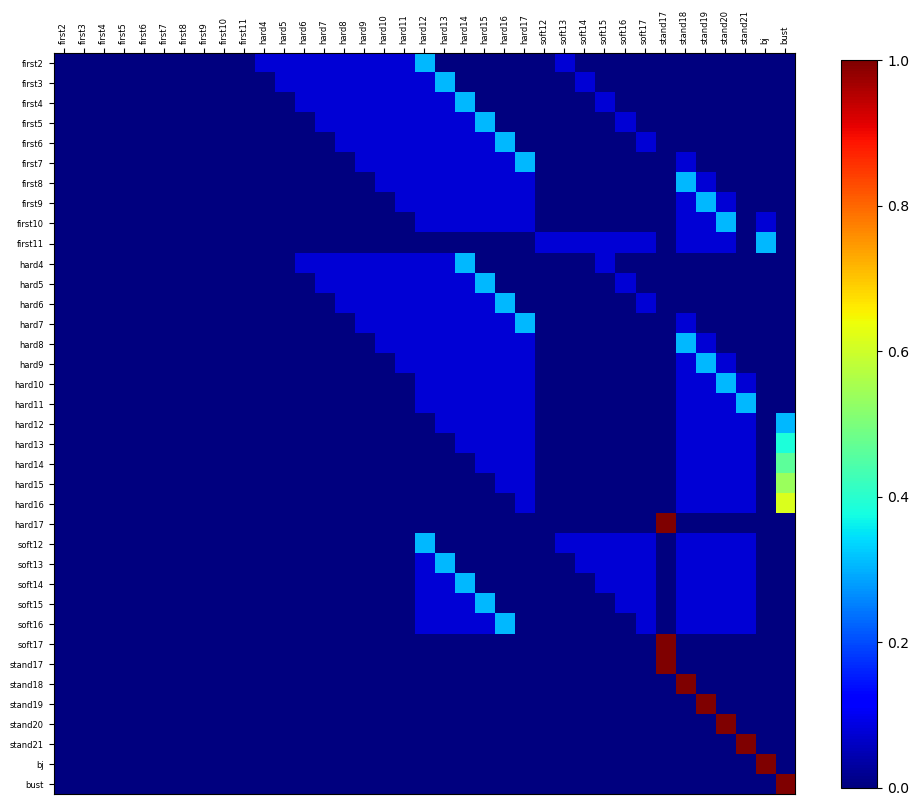

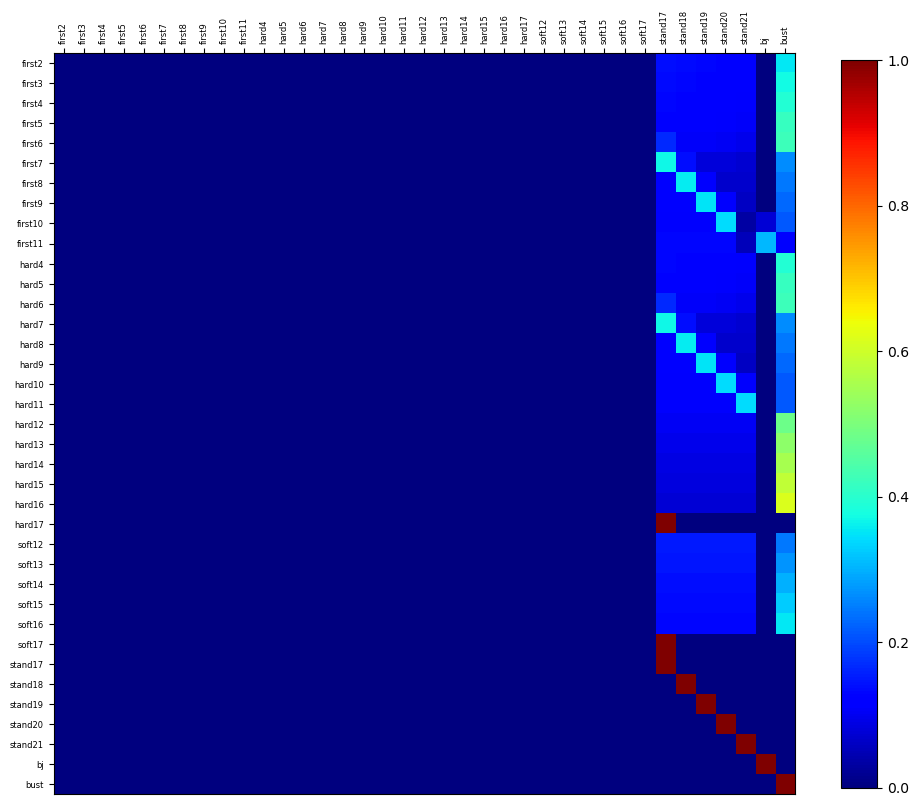

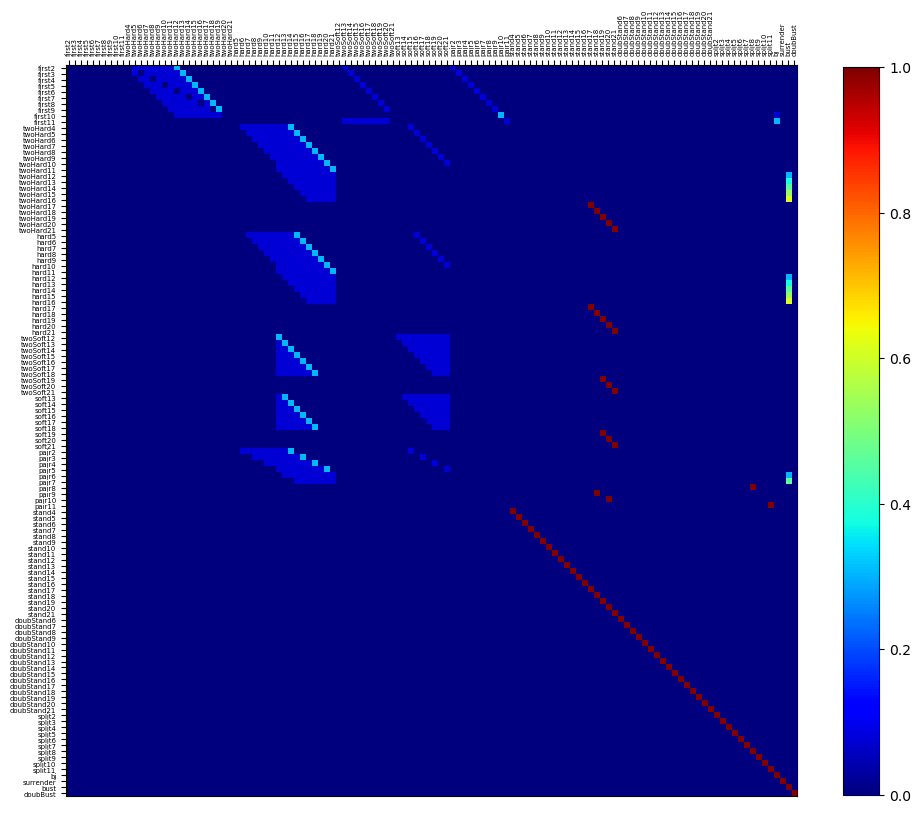

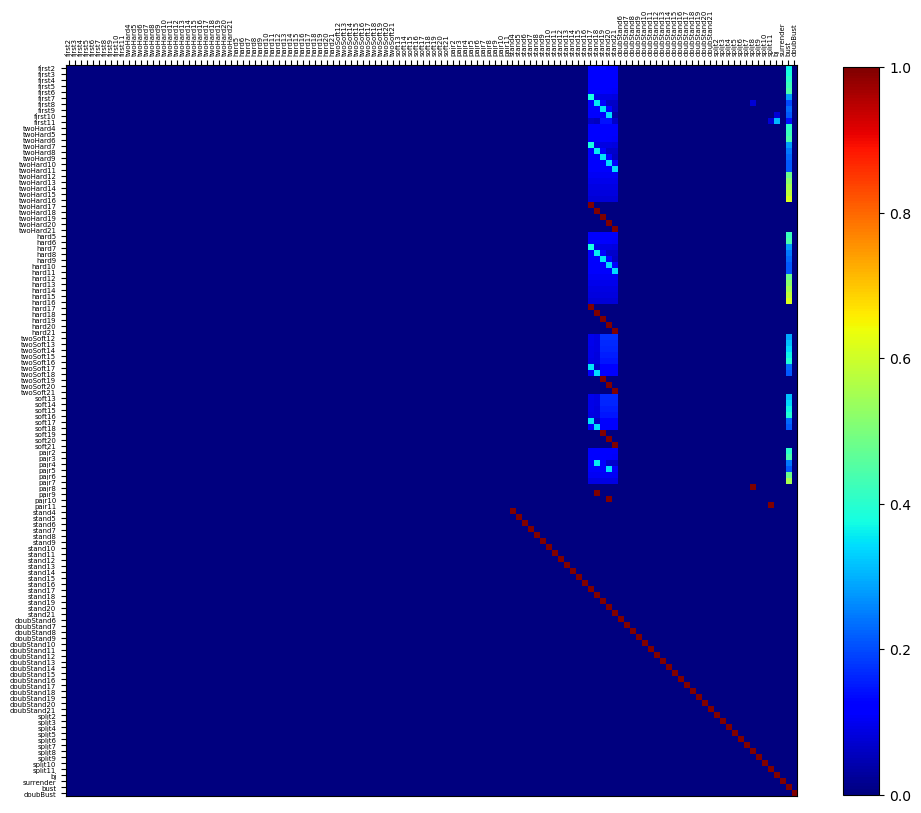

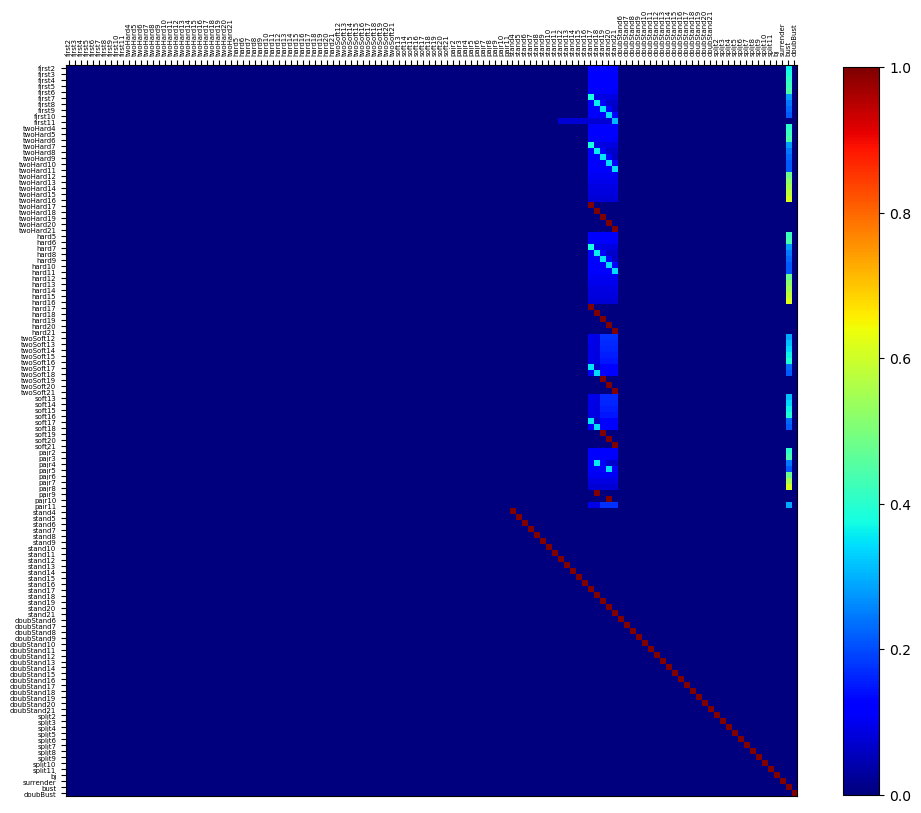

Player advantage (basic strategy): -0.005704661969060346


In [18]:
%run main.py